# TheLook E-commerce 분석

## 프로젝트 개요
전처리 노트북(`TheLook_Preprocessing.ipynb`)에서 생성한 2개의 데이터셋을 사용하여
이커머스 비즈니스의 핵심 지표를 분석합니다.

## 분석 항목

- **코호트 리텐션**  
- **퍼널 분석**  
- **LTV (Lifetime Value)**   

In [1]:
# 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 데이터 로드

In [2]:
df_session_log = pd.read_csv('/content/drive/MyDrive/TheLook/session_log.csv', parse_dates=['session_start_at'])
df_orders = pd.read_csv('/content/drive/MyDrive/TheLook/orders.csv', parse_dates=['signup_date', 'order_date', 'first_order_date'])

In [3]:
df_orders.head()

,order_id,user_id,product_id,status,sale_price,department,category,brand,gender,age,country,traffic_source,signup_date,first_order_date,order_date,diff_month_signup,diff_month_first_order
0,NaN,70259,NaN,NaN,NaN,NaN,NaN,NaN,F,12,Brasil,Email,2026-01-30 04:38:00,NaT,NaT,NaN,NaN
1,72542.0,57832,3450.0,Complete,47.880001,Women,Dresses,Evolution by Cyrus,F,12,Brasil,Organic,2026-01-03 14:13:00,2026-02-01 07:23:24,2026-02-01 07:23:24,1.0,0.0
2,72542.0,57832,5368.0,Complete,99.000000,Women,Pants & Capris,Jones New York,F,12,Brasil,Organic,2026-01-03 14:13:00,2026-02-01 07:23:24,2026-02-01 07:23:24,1.0,0.0
3,NaN,41683,NaN,NaN,NaN,NaN,NaN,NaN,F,12,Brasil,Search,2025-09-24 05:04:00,NaT,NaT,NaN,NaN
4,78084.0,62319,16591.0,Cancelled,28.950001,Men,Tops & Tees,Harley-Davidson,M,12,Brasil,Search,2025-05-02 07:52:00,2025-07-02 20:26:50,2025-07-02 20:26:50,2.0,0.0


In [4]:
df_session_log.head()

,session_id,user_id,session_start_at,landing_page,traffic_source,browser,has_landing,has_view,has_cart,has_purchase,view_to_cart_sec,cart_to_purchase_sec
0,0000bf30-37b8-4635-93e5-ebd759b4d830,87081.0,2025-12-30 02:44:17,home,Facebook,Firefox,1,1,1,1,116.0,142.0
1,000136bb-ec11-461c-bbb5-00451e7dc9d8,NaN,2025-08-09 00:45:00,department,Email,Chrome,1,1,1,0,240.0,NaN
2,00016d0d-6abc-4f07-9e82-4002674ec306,NaN,2025-06-25 14:27:00,product,YouTube,Chrome,1,1,1,0,540.0,NaN
3,00018851-651a-41c9-a153-3c91eca2b68b,NaN,2026-04-30 07:33:00,product,Adwords,Chrome,1,1,0,0,NaN,NaN
4,000195d9-def5-4513-809b-3893d8183d94,NaN,2026-01-09 18:59:00,department,Email,Chrome,1,1,1,0,1260.0,NaN


# 코호트 리텐션

같은 시기에 첫 구매를 한 유저 그룹이 이후 월에도 재구매를 하는지를 추적하는 분석입니다.

**코호트 정의** : `first_order_date` 기준 월 (첫 구매 월)

In [5]:
df_orders['diff_month_first_order'] = df_orders['diff_month_first_order'].astype('Int64')
df_orders['diff_month_signup'] = df_orders['diff_month_signup'].astype('Int64')

In [6]:
# 코호트(첫 구매 월)
df_orders['cohort_month'] = df_orders['first_order_date'].dt.to_period('M')

In [7]:
# 코호트×경과월별 고유 유저 수 집계
cohort_pivot = df_orders.pivot_table(index='cohort_month',
                              columns='diff_month_first_order',
                              values='user_id',
                              aggfunc='nunique')

In [8]:
# 리텐션 비율 계산 (Month 0 유저 수 대비 잔존율)
retention = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0)
retention

diff_month_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
cohort_month,,,,,,,,,,,,,,,,
2025-01,1.0,0.093023,0.139535,0.069767,0.093023,0.116279,0.023256,0.162791,0.069767,0.093023,0.069767,0.069767,0.023256,0.069767,0.046512,0.023256
2025-02,1.0,0.074074,0.037037,0.059259,0.059259,0.022222,0.059259,0.074074,0.051852,0.074074,0.111111,0.059259,0.074074,0.044444,0.074074,0.007407
2025-03,1.0,0.062500,0.084821,0.089286,0.093750,0.075893,0.107143,0.075893,0.071429,0.102679,0.071429,0.084821,0.075893,0.089286,0.004464,NaN
2025-04,1.0,0.059211,0.055921,0.059211,0.098684,0.095395,0.095395,0.078947,0.046053,0.101974,0.055921,0.078947,0.059211,0.003289,NaN,NaN
2025-05,1.0,0.086294,0.073604,0.076142,0.106599,0.071066,0.065990,0.081218,0.073604,0.058376,0.060914,0.098985,NaN,NaN,NaN,NaN
2025-06,1.0,0.077244,0.083507,0.089770,0.075157,0.068894,0.081420,0.091858,0.087683,0.085595,0.079332,0.008351,NaN,NaN,NaN,NaN
2025-07,1.0,0.092857,0.060714,0.089286,0.080357,0.085714,0.091071,0.083929,0.092857,0.071429,0.005357,NaN,NaN,NaN,NaN,NaN
2025-08,1.0,0.073806,0.081042,0.078148,0.094067,0.092619,0.088278,0.082489,0.095514,0.004342,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,1.0,0.092160,0.081155,0.096286,0.082531,0.072902,0.090784,0.096286,0.004127,NaN,NaN,NaN,NaN,NaN,NaN,NaN


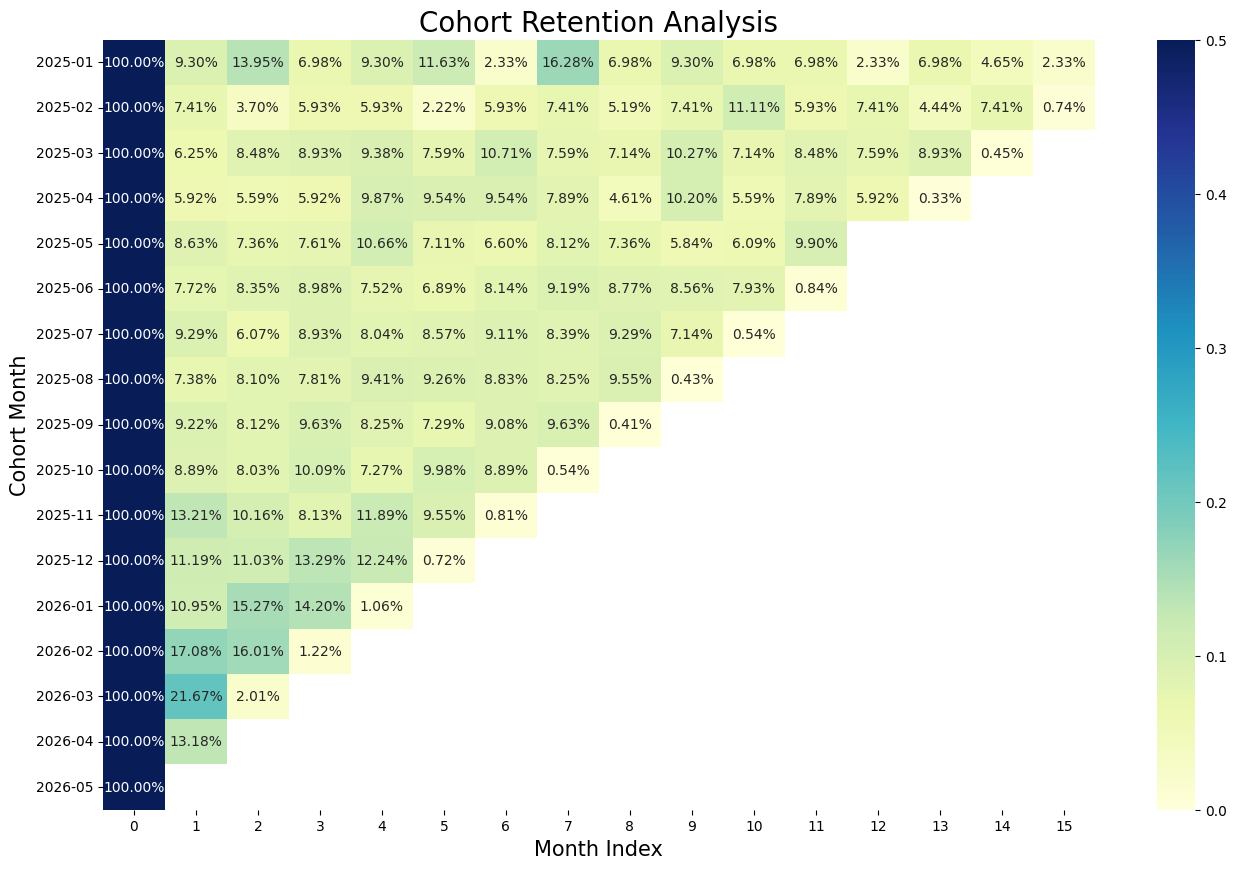

In [9]:
# 히트맵 시각화
plt.figure(figsize=(16, 10))
plt.title('Cohort Retention Analysis', fontsize=20)

sns.heatmap(retention,
            annot=True,
            fmt='.2%',
            cmap='YlGnBu',
            vmin=0,
            vmax=0.5)

plt.xlabel('Month Index', fontsize=15)
plt.ylabel('Cohort Month', fontsize=15)
plt.show()

# 퍼널 분석

세션 로그를 기반으로 `랜딩 → 상품 조회 → 장바구니 → 구매` 4단계 전환 퍼널을 분석합니다.


## 전체 퍼널

전체 세션 기준으로 단계별 전환율을 계산합니다.

- `step_conversion` : 바로 이전 단계 대비 전환율
- `overall_conversion` : 첫 단계(랜딩) 대비 누적 전환율

In [10]:
# 각 단계별 총 세션 수 계산
funnel_steps = ['has_landing', 'has_view', 'has_cart', 'has_purchase']
step_names = ['Total', 'Product View', 'Add to Cart', 'Purchase']
df_funnel = df_session_log[funnel_steps].sum().reset_index()
df_funnel.columns = ['step', 'count']
df_funnel['step'] = step_names

# 전환율(Conversion Rate) 계산
# 이전 단계 대비 잔존율
df_funnel['step_conversion'] = df_funnel['count'].pct_change().add(1).fillna(1).round(2)

# 첫 단계 대비 최종 전환율
df_funnel['overall_conversion'] = (df_funnel['count'] / df_funnel['count'][0]).round(2)

df_funnel

,step,count,step_conversion,overall_conversion
0,Total,144486,1.00,1.00
1,Product View,144486,1.00,1.00
2,Add to Cart,98929,0.68,0.68
3,Purchase,53757,0.54,0.37


In [11]:
# 퍼널 차트 시각화
fig = px.funnel(df_funnel, x='count', y='step',
                title='Funnel'
                )

fig.update_traces(
    textinfo="value+percent initial",
    marker = {
        "color": ["#1f77b4", "#47a0da", "#76c4ec", "#b0e0f6"],
        "line": {"width": 1, "color": "white"}
    },
    connector = {"line": {"color": "#b0e0f6", "dash": "dot", "width": 3}}) # 첫 단계 대비 비율 표시
fig.update_layout(title_x=0.5)
fig.show()

## 그룹별 퍼널 비교

In [12]:
# 그룹별 퍼널 비교 함수
def grouped_funnel(df, group_col):
    # 1. 그룹별로 각 퍼널 단계 도달 세션 합계 집계
    grouped_df = df.groupby(group_col)[funnel_steps].sum().reset_index()

    # 2. 단계별 전환율(Step-to-Step Conversion) 계산
    for i in range(1, len(funnel_steps)):
        prev_step = funnel_steps[i-1]
        curr_step = funnel_steps[i]
        grouped_df[f'{curr_step}_rate'] = (grouped_df[curr_step] / grouped_df[prev_step]).fillna(0).round(2)

    # 3. 전체 전환율(Total Conversion) 계산
    grouped_df['total_conv_rate'] = (grouped_df['has_purchase'] / grouped_df['has_landing']).round(2)
    display(grouped_df)

    # 4. 시각화를 위한 데이터 재구조화
    melted_df = grouped_df.melt(id_vars=group_col, value_vars=funnel_steps,
                                var_name='Step', value_name='Count')
    step_map = dict(zip(funnel_steps, step_names))
    melted_df['Step'] = melted_df['Step'].map(step_map)

    # 5. 그룹별 퍼널 차트 생성
    fig = px.funnel(melted_df, x='Count', y='Step', color=group_col,
                    title=f'Funnel Comparison by {group_col}')

    fig.update_traces(textinfo="value+percent initial")
    fig.show()


In [13]:
# Traffic Source별 퍼널
grouped_funnel(df_session_log, 'traffic_source')


,traffic_source,has_landing,has_view,has_cart,has_purchase,has_view_rate,has_cart_rate,has_purchase_rate,total_conv_rate
0,Adwords,43302,43302,29614,16089,1.0,0.68,0.54,0.37
1,Email,64882,64882,44449,24189,1.0,0.69,0.54,0.37
2,Facebook,14600,14600,10047,5446,1.0,0.69,0.54,0.37
3,Organic,7163,7163,4840,2651,1.0,0.68,0.55,0.37
4,YouTube,14539,14539,9979,5382,1.0,0.69,0.54,0.37


In [14]:
# Browser별 퍼널
grouped_funnel(df_session_log, 'browser')

,browser,has_landing,has_view,has_cart,has_purchase,has_view_rate,has_cart_rate,has_purchase_rate,total_conv_rate
0,Chrome,72337,72337,49441,26952,1.0,0.68,0.55,0.37
1,Firefox,29126,29126,20078,10884,1.0,0.69,0.54,0.37
2,IE,7213,7213,4895,2632,1.0,0.68,0.54,0.36
3,Other,7112,7112,4864,2620,1.0,0.68,0.54,0.37
4,Safari,28698,28698,19651,10669,1.0,0.68,0.54,0.37


In [15]:
# Landing Page별 퍼널
grouped_funnel(df_session_log, 'landing_page')

,landing_page,has_landing,has_view,has_cart,has_purchase,has_view_rate,has_cart_rate,has_purchase_rate,total_conv_rate
0,department,55230,55230,32424,9571,1.0,0.59,0.3,0.17
1,home,44186,44186,44186,44186,1.0,1.00,1.0,1.00
2,product,45070,45070,22319,0,1.0,0.50,0.0,0.00


# LTV (Lifetime Value)

유저 1명이 가입 이후 특정 시점까지 발생시킨 누적 매출의 평균입니다.

In [16]:
# 코호트(가입 월)
df_orders['signup_cohort'] = df_orders['signup_date'].dt.to_period('M')

# 코호트 규모 측정
cohort_size = df_orders.groupby('signup_cohort')['user_id'].nunique()

# LTV 계산
rev_pivot = df_orders.pivot_table(index='signup_cohort',
                              columns='diff_month_signup',
                              values='sale_price',
                              aggfunc='sum')
cum_rev = rev_pivot.cumsum(axis=1)
ltv= cum_rev.div(cohort_size, axis=0)

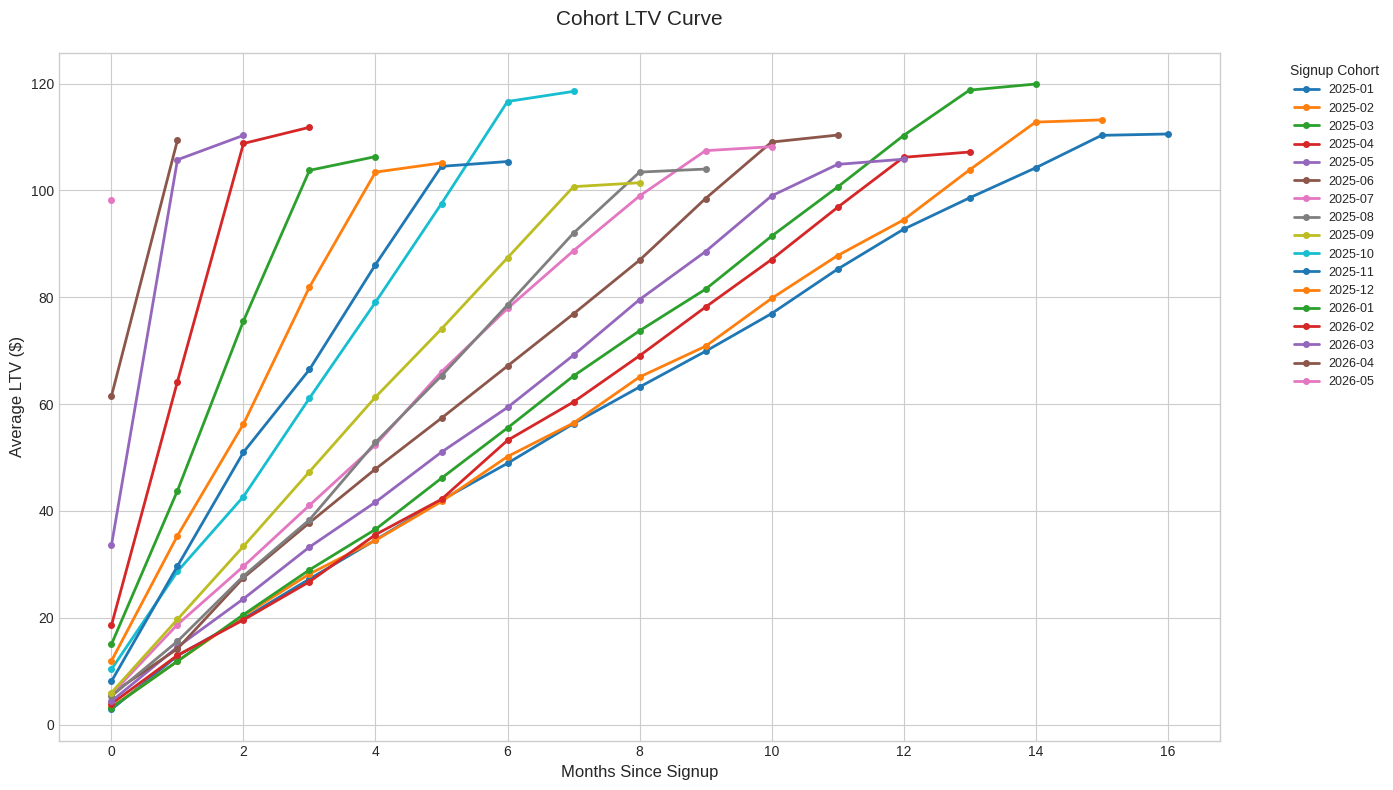

In [17]:
# 코호트별 LTV 곡선
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

for cohort in ltv.index:
    plt.plot(
        ltv.columns,
        ltv.loc[cohort],
        label=str(cohort),
        linewidth=2,
        marker='o',
        markersize=4
    )

plt.title('Cohort LTV Curve', fontsize=15, pad=20)
plt.xlabel('Months Since Signup', fontsize=12)
plt.ylabel('Average LTV ($)', fontsize=12)
plt.legend(title='Signup Cohort', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 가중 평균 LTV

In [18]:
# 가중 평균 LTV 산출
weighted_avg_ltv = {}

# 경과 월(0, 1, 2...)별로 루프를 돌며 계산
for col in cum_rev.columns:
    # 1. 해당 경과 월까지 데이터가 존재하는 코호트만 필터링
    valid_cohorts = cum_rev[col].dropna().index
    # 2. 유효한 코호트들의 해당 시점 누적 매출 총합
    total_revenue = cum_rev.loc[valid_cohorts, col].sum()
    # 3. 유효한 코호트들의 최초 가입자 수 총합
    total_users = cohort_size.loc[valid_cohorts].sum()
    # 4. 가중 평균 LTV 계산: (유효 코호트 누적 매출 합 / 유효 코호트 총 가입자 수)
    weighted_avg_ltv[col] = total_revenue / total_users

# 시각화를 위해 Series로 변환
weighted_avg_series = pd.Series(weighted_avg_ltv)

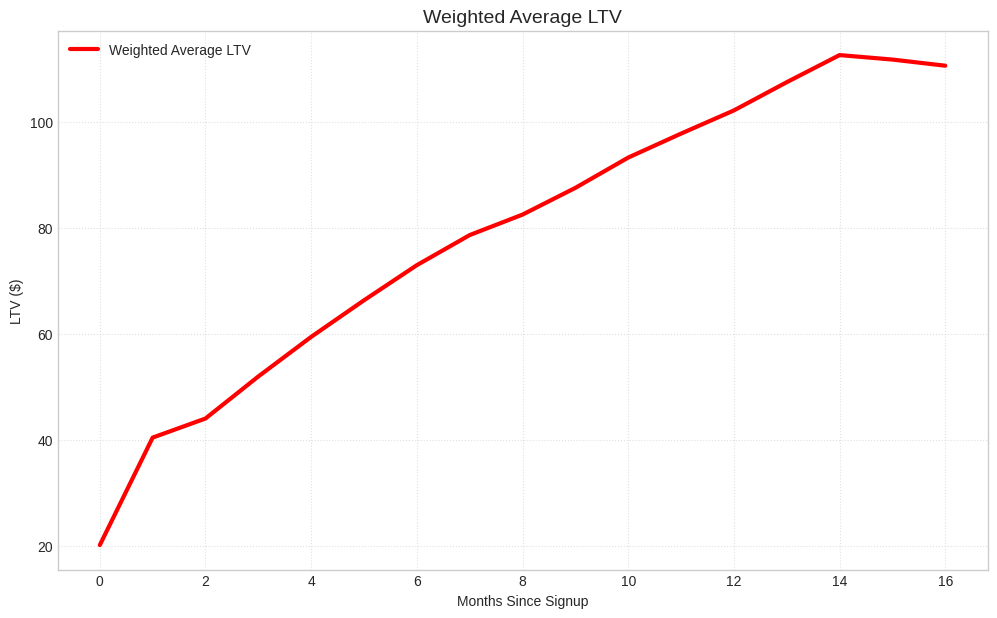

In [19]:
# 가중 평균 LTV 곡선
plt.figure(figsize=(12, 7))

plt.plot(weighted_avg_series.index, weighted_avg_series.values,
         color='red', linewidth=3, label='Weighted Average LTV')

plt.title('Weighted Average LTV', fontsize=14)
plt.xlabel('Months Since Signup')
plt.ylabel('LTV ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()